# Saari-style voting geometry in `VotingGeometry.jl`

This notebook is the Julia companion to the old `saari_geometry` Jupyter walkthrough. It shows the same geometry workflow, but through the monorepo architecture:

- `Preferences.jl` owns candidates, rankings, profiles, weights, restrictions, and linearization.
- `VotingGeometry.jl` owns canonical Saari bases, profile vectors, positional scoring, procedure hulls, simplex maps, decomposition, and plotting.

This version reflects the source audit in [`../docs/implementation_audit.md`](../docs/implementation_audit.md). The four-candidate sections now keep three distinctions explicit: Saari's procedure hull versus normalized score-share helpers, the candidate-tally tetrahedron versus the opened representation/profile tetrahedron, and matrix invertibility versus source-derived decomposition effects.

The examples below are synthetic. They intentionally avoid survey loading, DataFrames, imputation, ESEB-specific cleaning, and the transfer routine, which are outside this first `VotingGeometry.jl` pass.


## 0. Setup

Run this notebook from either the repo root or `VotingGeometry/examples/`. The setup cell activates `VotingGeometry/` and instantiates the package environment. `MPLBACKEND` is set before loading `VotingGeometry` so the plotting cells work in headless notebook checks; remove that line for an interactive Matplotlib backend.


In [35]:
import Pkg

function votinggeometry_project()
    candidates = unique(abspath.([
        pwd(),
        joinpath(pwd(), "VotingGeometry"),
        joinpath(pwd(), ".."),
        joinpath(pwd(), "..", "VotingGeometry"),
    ]))
    for dir in candidates
        project = joinpath(dir, "Project.toml")
        if isfile(project) && occursin("name = \"VotingGeometry\"", read(project, String))
            return dir
        end
    end
    error("Could not locate VotingGeometry/Project.toml. Start Jupyter from the repo root or VotingGeometry/examples/.")
end

Pkg.activate(votinggeometry_project())
Pkg.instantiate()

ENV["MPLBACKEND"] = get(ENV, "MPLBACKEND", "Agg")

using LinearAlgebra
using Preferences
using VotingGeometry
using PythonPlot

VERSION


  Activating project at `~/Sync/Projects/polarization_paper/replication_package_reboot/VotingGeometry`


v"1.11.9"

## 1. API map

The old Python notebook mixed profile construction, table wrangling, geometry, scoring, and plotting. In the Julia package split, profile construction is delegated to `Preferences.jl`; `VotingGeometry.jl` starts once we have strict complete `Profile` or `WeightedProfile` objects.


In [36]:
api_inventory = [
    (responsibility = "candidate universe", package = "Preferences.jl", examples = "CandidatePool, candidates"),
    (responsibility = "ballots and profiles", package = "Preferences.jl", examples = "StrictRank, WeakRank, Profile, WeightedProfile"),
    (responsibility = "profile preprocessing", package = "Preferences.jl", examples = "linearize, restrict, weights"),
    (responsibility = "canonical Saari order", package = "VotingGeometry.jl", examples = "SaariBasis3, SaariBasis4, CANONICAL_4C_IDS"),
    (responsibility = "profile vectors", package = "VotingGeometry.jl", examples = "profile_vector, profile_counts"),
    (responsibility = "positional scoring", package = "VotingGeometry.jl", examples = "get_4c_w_s, plurality_4c_q_s"),
    (responsibility = "Saari procedure hull", package = "VotingGeometry.jl", examples = "procedure_hull_4c, procedure_hull_barycentric_4c"),
    (responsibility = "simplex geometry", package = "VotingGeometry.jl", examples = "tern2cart, tetrahedron_points_from_profile"),
    (responsibility = "tetrahedron plots", package = "VotingGeometry.jl", examples = "plot_candidate_tally_tetrahedron, plot_opened_representation_tetrahedron"),
    (responsibility = "decomposition", package = "VotingGeometry.jl", examples = "decompose_profile, group_component, kernel_profile_4c"),
    (responsibility = "decomposition plots", package = "VotingGeometry.jl", examples = "plot_decomposition_coefficients, plot_decomposition_reconstruction_check"),
]

api_inventory


11-element Vector{@NamedTuple{responsibility::String, package::String, examples::String}}:
 (responsibility = "candidate universe", package = "Preferences.jl", examples = "CandidatePool, candidates")
 (responsibility = "ballots and profiles", package = "Preferences.jl", examples = "StrictRank, WeakRank, Profile, WeightedProfile")
 (responsibility = "profile preprocessing", package = "Preferences.jl", examples = "linearize, restrict, weights")
 (responsibility = "canonical Saari order", package = "VotingGeometry.jl", examples = "SaariBasis3, SaariBasis4, CANONICAL_4C_IDS")
 (responsibility = "profile vectors", package = "VotingGeometry.jl", examples = "profile_vector, profile_counts")
 (responsibility = "positional scoring", package = "VotingGeometry.jl", examples = "get_4c_w_s, plurality_4c_q_s")
 (responsibility = "Saari procedure hull", package = "VotingGeometry.jl", examples = "procedure_hull_4c, procedure_hull_barycentric_4c")
 (responsibility = "simplex geometry", package = "Votin

## 2. Canonical orders

The Saari bases are not lexicographic permutation orders. Their explicit order is part of the mathematical interface, especially for the 24-dimensional decomposition. `CANONICAL_4C_IDS` follows Saari's Figure 8 voter-type order; opened-tetrahedron plotting positions are a separate display convention. Always project `Preferences` profiles through `SaariBasis3` or `SaariBasis4` instead of hand-building vectors in a different order.


In [37]:
pool3_demo = CandidatePool([:Alckmin, :Bolsonaro, :Ciro])
basis3_demo = SaariBasis3(pool3_demo)

canonical3 = [
    (index = i, ranking = ranking_labels(basis3_demo)[i], ids = Tuple(canonical_permutations(basis3_demo)[i]))
    for i in eachindex(canonical_permutations(basis3_demo))
]

canonical3


6-element Vector{@NamedTuple{index::Int64, ranking::String, ids::Tuple{Int64, Int64, Int64}}}:
 (index = 1, ranking = "Alckmin>Bolsonaro>Ciro", ids = (1, 2, 3))
 (index = 2, ranking = "Alckmin>Ciro>Bolsonaro", ids = (1, 3, 2))
 (index = 3, ranking = "Ciro>Alckmin>Bolsonaro", ids = (3, 1, 2))
 (index = 4, ranking = "Ciro>Bolsonaro>Alckmin", ids = (3, 2, 1))
 (index = 5, ranking = "Bolsonaro>Ciro>Alckmin", ids = (2, 3, 1))
 (index = 6, ranking = "Bolsonaro>Alckmin>Ciro", ids = (2, 1, 3))

In [38]:
pool4_demo = CandidatePool([:A, :B, :C, :D])
basis4_demo = SaariBasis4(pool4_demo)

canonical4 = [
    (index = i, ranking = ranking_labels(basis4_demo)[i], ids = Tuple(canonical_permutations(basis4_demo)[i]))
    for i in eachindex(canonical_permutations(basis4_demo))
]

canonical4


24-element Vector{@NamedTuple{index::Int64, ranking::String, ids::NTuple{4, Int64}}}:
 (index = 1, ranking = "A>B>C>D", ids = (1, 2, 3, 4))
 (index = 2, ranking = "A>C>B>D", ids = (1, 3, 2, 4))
 (index = 3, ranking = "C>A>B>D", ids = (3, 1, 2, 4))
 (index = 4, ranking = "C>B>A>D", ids = (3, 2, 1, 4))
 (index = 5, ranking = "B>C>A>D", ids = (2, 3, 1, 4))
 (index = 6, ranking = "B>A>C>D", ids = (2, 1, 3, 4))
 (index = 7, ranking = "A>C>D>B", ids = (1, 3, 4, 2))
 (index = 8, ranking = "A>D>C>B", ids = (1, 4, 3, 2))
 (index = 9, ranking = "D>A>C>B", ids = (4, 1, 3, 2))
 (index = 10, ranking = "D>C>A>B", ids = (4, 3, 1, 2))
 (index = 11, ranking = "C>D>A>B", ids = (3, 4, 1, 2))
 (index = 12, ranking = "C>A>D>B", ids = (3, 1, 4, 2))
 (index = 13, ranking = "C>B>D>A", ids = (3, 2, 4, 1))
 (index = 14, ranking = "C>D>B>A", ids = (3, 4, 2, 1))
 (index = 15, ranking = "D>C>B>A", ids = (4, 3, 2, 1))
 (index = 16, ranking = "D>B>C>A", ids = (4, 2, 3, 1))
 (index = 17, ranking = "B>D>C>A", ids = (2

## 3. Building profiles from counts

The examples below use compact count vectors for readability. The helper expands counts into strict `Preferences.Profile` objects, then immediately projects them back through the canonical basis. In real code, upstream data should become `Profile` or `WeightedProfile` first; this helper is only for examples.


In [39]:
function profile_from_counts(pool::CandidatePool, basis::SaariBasis, counts)
    perms = canonical_permutations(basis)
    length(counts) == length(perms) || throw(ArgumentError("count vector length does not match basis"))

    sample = StrictRank(pool, collect(perms[1]))
    ballots = Vector{typeof(sample)}()
    for (perm, count) in zip(perms, counts)
        count >= 0 || throw(ArgumentError("counts must be nonnegative"))
        for _ in 1:Int(count)
            push!(ballots, StrictRank(pool, collect(perm)))
        end
    end
    return Profile(pool, ballots)
end

function profile_rows(basis, vector)
    labels = ranking_labels(basis)
    total = sum(vector)
    return [
        (index = i, ranking = labels[i], count = vector[i], share = total == 0 ? 0.0 : round(vector[i] / total; digits = 4))
        for i in eachindex(vector)
    ]
end

function positional_rows(methods, labels)
    rows = NamedTuple[]
    for (method, scores) in methods
        order = winner_order(scores, labels)
        for i in eachindex(labels)
            push!(rows, (
                method = method,
                candidate = labels[i],
                score = round(scores[i]; digits = 4),
                winner = labels[i] == order[1],
            ))
        end
    end
    return rows
end


positional_rows (generic function with 1 method)

## 4. Three candidates: a beverage profile

The 3-candidate canonical order is `ABC, ACB, CAB, CBA, BCA, BAC`. Here the candidates are `Tea`, `Milk`, and `Wine`. The counts are synthetic but chosen to make the geometric interpretation visible: plurality favors first-place support, while Borda and antiplurality respond to lower-rank information.


In [40]:
beverage_pool = CandidatePool([:Tea, :Milk, :Wine])
beverage_basis = SaariBasis3(beverage_pool)
beverage_counts = [4, 2, 7, 1, 9, 3]
beverage_profile = profile_from_counts(beverage_pool, beverage_basis, beverage_counts)

p3_freq = profile_vector(beverage_profile, beverage_basis; normalize = false)
p3_prop = profile_vector(beverage_profile, beverage_basis; normalize = true)

profile_rows(beverage_basis, p3_freq)


6-element Vector{@NamedTuple{index::Int64, ranking::String, count::Float64, share::Float64}}:
 (index = 1, ranking = "Tea>Milk>Wine", count = 4.0, share = 0.1538)
 (index = 2, ranking = "Tea>Wine>Milk", count = 2.0, share = 0.0769)
 (index = 3, ranking = "Wine>Tea>Milk", count = 7.0, share = 0.2692)
 (index = 4, ranking = "Wine>Milk>Tea", count = 1.0, share = 0.0385)
 (index = 5, ranking = "Milk>Wine>Tea", count = 9.0, share = 0.3462)
 (index = 6, ranking = "Milk>Tea>Wine", count = 3.0, share = 0.1154)

In [41]:
labels3 = Preferences.candidates(beverage_pool)
methods3 = [
    (:plurality, plurality_3a(p3_prop)),
    (:borda, borda_3a(p3_prop)),
    (:antiplurality, antiplurality_3a(p3_prop)),
]

positional_rows(methods3, labels3)


9-element Vector{NamedTuple}:
 (method = :plurality, candidate = :Tea, score = 0.2308, winner = false)
 (method = :plurality, candidate = :Milk, score = 0.4615, winner = true)
 (method = :plurality, candidate = :Wine, score = 0.3077, winner = false)
 (method = :borda, candidate = :Tea, score = 0.2821, winner = false)
 (method = :borda, candidate = :Milk, score = 0.3718, winner = true)
 (method = :borda, candidate = :Wine, score = 0.3462, winner = false)
 (method = :antiplurality, candidate = :Tea, score = 0.3077, winner = false)
 (method = :antiplurality, candidate = :Milk, score = 0.3269, winner = false)
 (method = :antiplurality, candidate = :Wine, score = 0.3654, winner = true)

### 4.1 The Saari triangle

`plot_saari_triangle` maps the three positional outcomes into the triangle whose vertices are the three candidates. The dashed segment connects plurality and antiplurality; the Borda point lies on that line in the 3-candidate positional family.


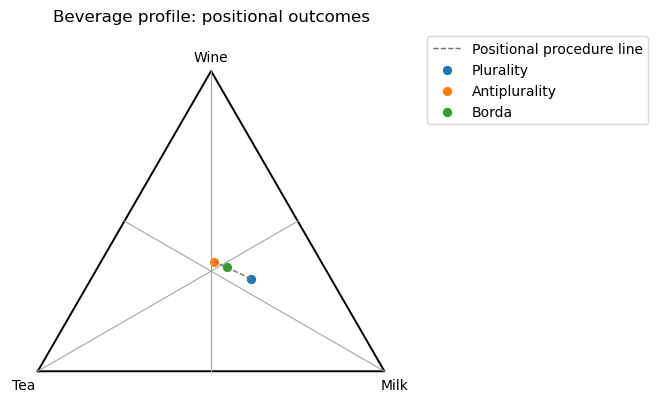

Python: <Axes: title={'center': 'Beverage profile: positional outcomes'}>

In [42]:
ax = plot_saari_triangle(p3_prop; labels = String.(labels3))
ax.set_title("Beverage profile: positional outcomes")
ax


In [43]:
triangle_points_from_profile(p3_prop)


Dict{Symbol, Tuple{Float64, Float64}} with 3 entries:
  :antiplurality => (0.509615, 0.316432)
  :borda         => (0.544872, 0.299778)
  :plurality     => (0.615385, 0.266469)

### 4.2 Weighted profiles use the same bridge

`WeightedProfile` lives in `Preferences.jl`. `VotingGeometry.profile_vector` reads the ballot weights and accumulates weighted mass in the same canonical coordinates.


In [44]:
weighted_ballots = [
    StrictRank(beverage_pool, [:Tea, :Milk, :Wine]),
    StrictRank(beverage_pool, [:Milk, :Wine, :Tea]),
    StrictRank(beverage_pool, [:Wine, :Tea, :Milk]),
]
weighted_profile = WeightedProfile(beverage_pool, weighted_ballots, [1.5, 3.0, 2.0])

weighted_freq = profile_vector(weighted_profile, beverage_basis; normalize = false)
weighted_prop = profile_vector(weighted_profile, beverage_basis; normalize = true)

(profile_rows(beverage_basis, weighted_freq), sum(weighted_prop))


(@NamedTuple{index::Int64, ranking::String, count::Float64, share::Float64}[(index = 1, ranking = "Tea>Milk>Wine", count = 1.5, share = 0.2308), (index = 2, ranking = "Tea>Wine>Milk", count = 0.0, share = 0.0), (index = 3, ranking = "Wine>Tea>Milk", count = 2.0, share = 0.3077), (index = 4, ranking = "Wine>Milk>Tea", count = 0.0, share = 0.0), (index = 5, ranking = "Milk>Wine>Tea", count = 3.0, share = 0.4615), (index = 6, ranking = "Milk>Tea>Wine", count = 0.0, share = 0.0)], 1.0)

### 4.3 Weak profiles must be linearized first

The geometry basis is over strict complete rankings. If upstream data has ties or incomplete ranks, use `Preferences.linearize` before projection. `VotingGeometry` intentionally refuses weak profiles instead of silently choosing a tie-break rule.


In [45]:
weak_profile = Profile(beverage_pool, [
    WeakRank(beverage_pool, Dict(:Tea => 1, :Milk => 1, :Wine => 2)),
])

try
    profile_vector(weak_profile, beverage_basis)
catch err
    sprint(showerror, err)
end


"ArgumentError: VotingGeometry requires strict complete profiles. Use Preferences.linearize first."

## 5. Four candidates: a Brazil-like synthetic profile

The next profile uses candidate names from the Brazil/ESEB domain but remains fully synthetic. It demonstrates the four-candidate canonical basis, positional scoring, procedure-hull conventions, tetrahedron layouts, and 24-dimensional decomposition without any survey adapter.


In [46]:
brazil_pool = CandidatePool([:Alckmin, :Bolsonaro, :Ciro, :Haddad])
brazil_basis = SaariBasis4(brazil_pool)
labels4 = Preferences.candidates(brazil_pool)

brazil_counts = [
    18, 52, 25, 12, 20, 8,
    5, 7, 10, 9, 4, 12,
    8, 15, 9, 11, 13, 17,
    16, 10, 6, 8, 7, 14,
]

brazil_profile = profile_from_counts(brazil_pool, brazil_basis, brazil_counts)
p4_freq = profile_vector(brazil_profile, brazil_basis; normalize = false)
p4_prop = profile_vector(brazil_profile, brazil_basis; normalize = true)

(first(profile_rows(brazil_basis, p4_freq), 8), sum(p4_freq), sum(p4_prop))


(@NamedTuple{index::Int64, ranking::String, count::Float64, share::Float64}[(index = 1, ranking = "Alckmin>Bolsonaro>Ciro>Haddad", count = 18.0, share = 0.057), (index = 2, ranking = "Alckmin>Ciro>Bolsonaro>Haddad", count = 52.0, share = 0.1646), (index = 3, ranking = "Ciro>Alckmin>Bolsonaro>Haddad", count = 25.0, share = 0.0791), (index = 4, ranking = "Ciro>Bolsonaro>Alckmin>Haddad", count = 12.0, share = 0.038), (index = 5, ranking = "Bolsonaro>Ciro>Alckmin>Haddad", count = 20.0, share = 0.0633), (index = 6, ranking = "Bolsonaro>Alckmin>Ciro>Haddad", count = 8.0, share = 0.0253), (index = 7, ranking = "Alckmin>Ciro>Haddad>Bolsonaro", count = 5.0, share = 0.0158), (index = 8, ranking = "Alckmin>Haddad>Ciro>Bolsonaro", count = 7.0, share = 0.0222)], 316.0, 1.0)

### 5.1 Score vectors and Saari's procedure hull

For four candidates, an admissible normalized scoring vector is `(1, s1, s2, 0)` with `0 <= s2 <= s1 <= 1`. Saari's procedure hull uses the score-vector decomposition

`(1, s1, s2, 0) = (1-s1)E1 + (s1-s2)E2 + s2*E3`,

where `E1`, `E2`, and `E3` are vote-for-one, vote-for-two, and vote-for-three. Under this source convention Borda `(1, 2/3, 1/3, 0)` is the centroid of the triangle.

`q_s_4candidates` returns true candidate score shares by dividing raw scores by profile mass and scoring-rule mass. The old per-rule-mass tally is available as `score_tally_per_rule_mass_4c`. Candidate score shares are useful for q-image displays and do not change candidate ordering for a fixed scoring vector, but they are not Saari's procedure-hull coordinate system and are not used below to define the hull.


In [47]:
example_s1, example_s2 = 0.25, 0.10

(
    scoring_vector = (1.0, example_s1, example_s2, 0.0),
    saari_hull_barycentric = procedure_hull_barycentric_4c(example_s1, example_s2),
    borda_hull_barycentric = procedure_hull_barycentric_4c(2 / 3, 1 / 3),
    vote_matrix = standard_vote_matrix(example_s1, example_s2),
)


(scoring_vector = (1.0, 0.25, 0.1, 0.0), saari_hull_barycentric = (0.75, 0.15, 0.1), borda_hull_barycentric = (0.33333333333333337, 0.3333333333333333, 0.3333333333333333), vote_matrix = [1.0 1.0 … 1.0 1.0; 0.25 0.1 … 0.1 0.25; 0.1 0.25 … 0.0 0.0; 0.0 0.0 … 0.25 0.1])

In [48]:
methods4 = [
    (:plurality_q, plurality_4c_q_s(p4_freq)),
    (:vote_for_two_q, vote_for_two_4c_q_s(p4_freq)),
    (:antiplurality_q, antiplurality_4c_q_s(p4_freq)),
    (:borda_q, borda_4c_q_s(p4_freq)),
]

positional_rows(methods4, labels4)


16-element Vector{NamedTuple}:
 (method = :plurality_q, candidate = :Alckmin, score = 103.0, winner = true)
 (method = :plurality_q, candidate = :Bolsonaro, score = 84.0, winner = false)
 (method = :plurality_q, candidate = :Ciro, score = 76.0, winner = false)
 (method = :plurality_q, candidate = :Haddad, score = 53.0, winner = false)
 (method = :vote_for_two_q, candidate = :Alckmin, score = 91.0, winner = false)
 (method = :vote_for_two_q, candidate = :Bolsonaro, score = 76.5, winner = false)
 (method = :vote_for_two_q, candidate = :Ciro, score = 94.0, winner = true)
 (method = :vote_for_two_q, candidate = :Haddad, score = 54.5, winner = false)
 (method = :antiplurality_q, candidate = :Alckmin, score = 81.0, winner = false)
 (method = :antiplurality_q, candidate = :Bolsonaro, score = 89.6667, winner = true)
 (method = :antiplurality_q, candidate = :Ciro, score = 85.0, winner = false)
 (method = :antiplurality_q, candidate = :Haddad, score = 60.3333, winner = false)
 (method = :borda_q

### 5.2 Procedure-hull points for this profile

For a fixed profile, Saari's four-candidate procedure hull is the triangle spanned by raw vote-for-one, vote-for-two, and vote-for-three tallies. The Borda tally is the arithmetic average of those three raw tallies. When we draw the q-image inside the candidate-tally tetrahedron, the plotting layer uses candidate score shares so the display coordinates live in the simplex.


In [49]:
hull4 = procedure_hull_4c(p4_freq; labels = String.(labels4))

function rounded_tuple(v; digits = 3)
    return Tuple(round.(collect(v); digits = digits))
end

saari_borda_centroid = (
    hull4.vertices.vote_for_one .+
    hull4.vertices.vote_for_two .+
    hull4.vertices.vote_for_three
) ./ 3

sample_s1, sample_s2 = 0.75, 0.25

(
    borda_barycentric = hull4.borda_barycentric,
    borda_is_raw_centroid = isapprox(hull4.borda_point, saari_borda_centroid),
    sample_raw_hull_identity = isapprox(
        procedure_hull_point_4c(p4_freq, sample_s1, sample_s2),
        get_4c_w_s(p4_freq, sample_s1, sample_s2),
    ),
    raw_vertices = (
        vote_for_one = rounded_tuple(hull4.vertices.vote_for_one),
        vote_for_two = rounded_tuple(hull4.vertices.vote_for_two),
        vote_for_three = rounded_tuple(hull4.vertices.vote_for_three),
    ),
)


(borda_barycentric = (0.33333333333333337, 0.3333333333333333, 0.3333333333333333), borda_is_raw_centroid = true, sample_raw_hull_identity = true, raw_vertices = (vote_for_one = (103.0, 84.0, 76.0, 53.0), vote_for_two = (182.0, 153.0, 188.0, 109.0), vote_for_three = (243.0, 269.0, 255.0, 181.0)))

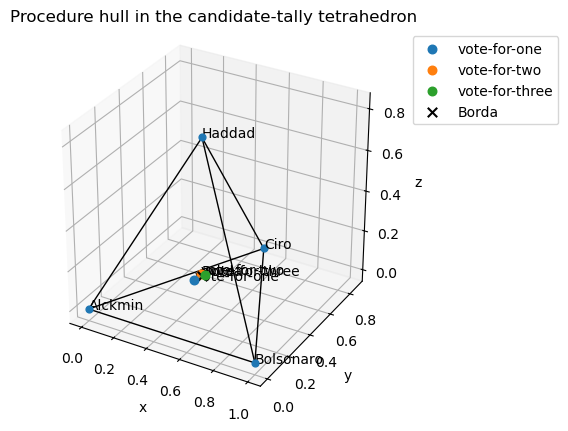

Python: <Axes3D: title={'center': 'q-normalized procedure-hull image in the candidate-tally tetrahedron'}, xlabel='x', ylabel='y', zlabel='z'>

In [50]:
ax = plot_procedure_hull_4c(p4_freq; labels = String.(labels4), convention = :saari)
ax.set_title("q-normalized procedure-hull image in the candidate-tally tetrahedron")
ax


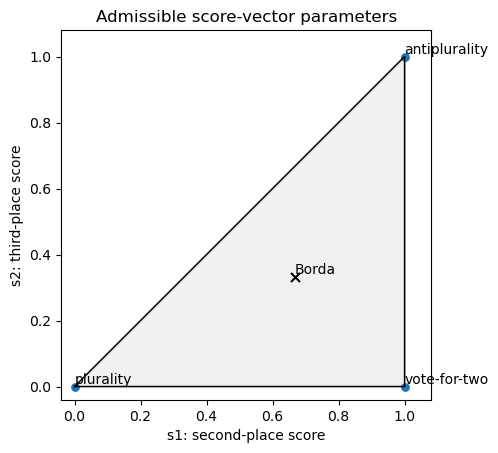

Python: <Axes: title={'center': 'Saari score-vector parameter space'}, xlabel='s1: second-place score', ylabel='s2: third-place score'>

In [51]:
ax = plot_procedure_hull_parameter_triangle()
ax.set_title("Saari score-vector parameter space")
ax


### 5.3 Comparison regions over positional parameter space

The admissible scoring simplex is `0 <= s2 <= s1 <= 1`. The package helper below sweeps a diagnostic grid over that parameter triangle and overlays approximate score-comparison regions. Use `positional_comparison_region_exact_table` or `plot_positional_comparison_regions_exact` for exact polygon areas from half-plane clipping. Internally the grid helper uses `q_s_4candidates`, but that division is by a positive scalar for each `(s1, s2)`, so pairwise score comparisons are identical to raw `get_4c_w_s` comparisons at each grid point.


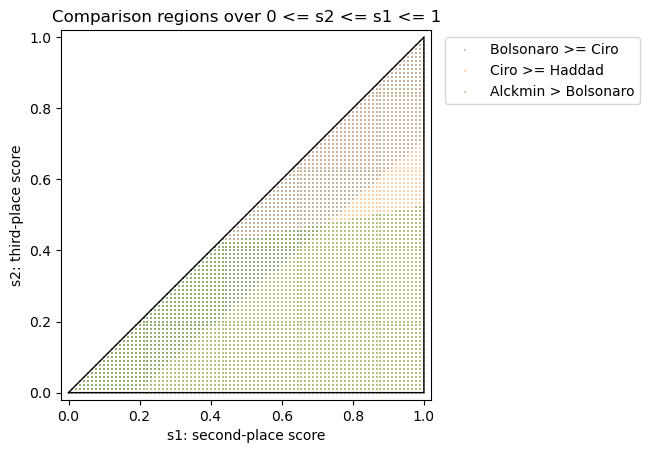

Python: <Axes: title={'center': 'Diagnostic grid comparison regions over Saari parameter space'}, xlabel='s1: second-place score', ylabel='s2: third-place score'>

In [52]:
plot_positional_comparison_regions(p4_freq, labels4; resolution = 91)


In [53]:
positional_comparison_region_table(p4_freq, labels4; resolution = 51)


3-element Vector{@NamedTuple{comparison::String, left::String, op::Symbol, right::String, true_count::Int64, grid_count::Int64, parameter_space_proportion::Float64}}:
 (comparison = "Bolsonaro >= Ciro", left = "Bolsonaro", op = :>=, right = "Ciro", true_count = 561, grid_count = 1326, parameter_space_proportion = 0.4230769230769231)
 (comparison = "Ciro >= Haddad", left = "Ciro", op = :>=, right = "Haddad", true_count = 1326, grid_count = 1326, parameter_space_proportion = 1.0)
 (comparison = "Alckmin > Bolsonaro", left = "Alckmin", op = :>, right = "Bolsonaro", true_count = 958, grid_count = 1326, parameter_space_proportion = 0.722473604826546)

## 6. Candidate dropping and the three-candidate triangle

Alternative-set sensitivity is handled by `Preferences.restrict`, not by `VotingGeometry`. After restricting a profile to three candidates, we build a `SaariBasis3` for the restricted candidate pool and use the usual triangle tools.


In [54]:
drop_rows = NamedTuple[]
for dropped in labels4
    keep = [candidate for candidate in labels4 if candidate != dropped]
    restricted_profile, restricted_pool, _ = restrict(brazil_profile, keep)
    restricted_basis = SaariBasis3(restricted_pool)
    restricted_vector = profile_vector(restricted_profile, restricted_basis; normalize = true)
    borda_scores = borda_3a(restricted_vector)
    push!(drop_rows, (
        dropped = dropped,
        kept = join(String.(keep), ", "),
        borda_winner = winner_order(borda_scores, keep)[1],
        plurality_winner = winner_order(plurality_3a(restricted_vector), keep)[1],
        antiplurality_winner = winner_order(antiplurality_3a(restricted_vector), keep)[1],
    ))
end

drop_rows


4-element Vector{NamedTuple}:
 (dropped = :Alckmin, kept = "Bolsonaro, Ciro, Haddad", borda_winner = :Ciro, plurality_winner = :Ciro, antiplurality_winner = :Bolsonaro)
 (dropped = :Bolsonaro, kept = "Alckmin, Ciro, Haddad", borda_winner = :Alckmin, plurality_winner = :Alckmin, antiplurality_winner = :Ciro)
 (dropped = :Ciro, kept = "Alckmin, Bolsonaro, Haddad", borda_winner = :Alckmin, plurality_winner = :Alckmin, antiplurality_winner = :Bolsonaro)
 (dropped = :Haddad, kept = "Alckmin, Bolsonaro, Ciro", borda_winner = :Alckmin, plurality_winner = :Alckmin, antiplurality_winner = :Ciro)

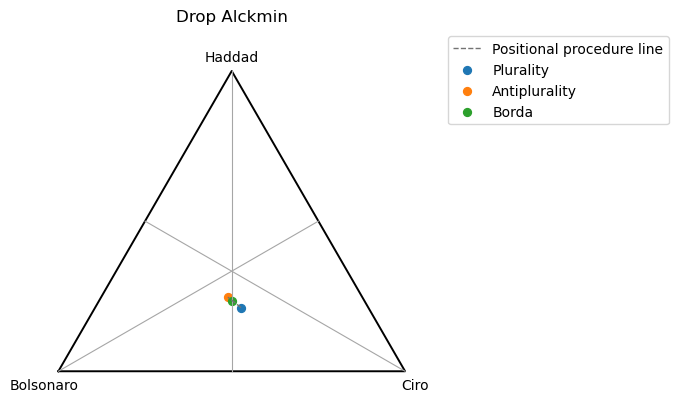

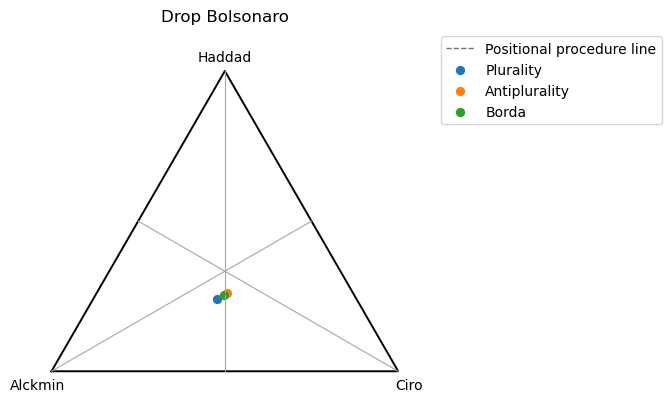

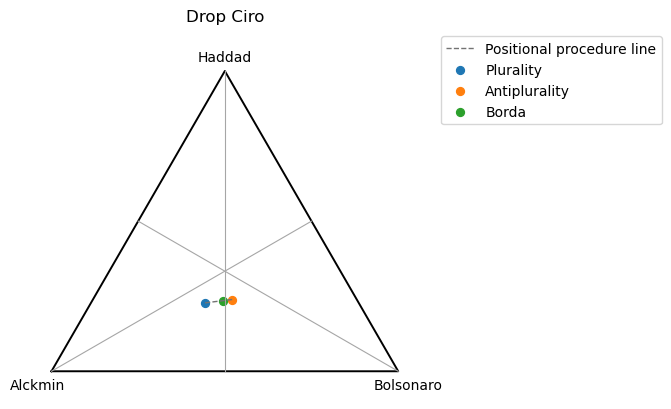

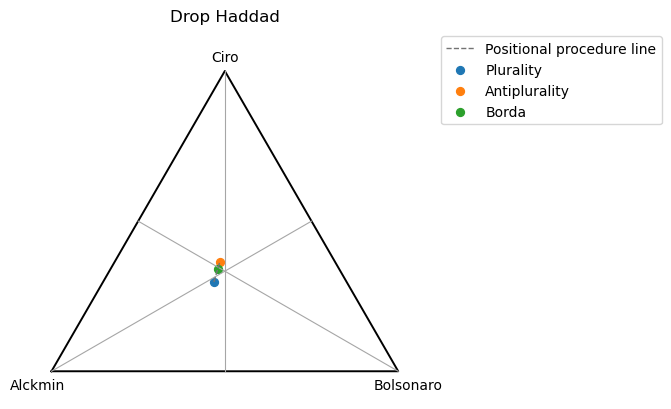

In [55]:
for dropped in labels4
    keep = [candidate for candidate in labels4 if candidate != dropped]
    restricted_profile, restricted_pool, _ = restrict(brazil_profile, keep)
    restricted_basis = SaariBasis3(restricted_pool)
    restricted_vector = profile_vector(restricted_profile, restricted_basis; normalize = true)
    ax_drop = plot_saari_triangle(restricted_vector; labels = String.(keep))
    ax_drop.set_title("Drop $(String(dropped))")
end

nothing


## 7. Tetrahedral views of four-candidate profiles

Saari uses two distinct tetrahedral objects, and the package now names them separately.

- The candidate-tally tetrahedron is the simplex `x_A+x_B+x_C+x_D=1`; candidate score shares can be displayed there.
- The opened representation tetrahedron is the profile/ranking-region picture; cutting the tetrahedron along edges from one vertex lays out the 24 ranking regions, with the missing candidate bottom-ranked on each face.

Profile frequencies belong on the opened representation tetrahedron. Candidate score shares belong in the candidate-tally tetrahedron. The Saari procedure hull is defined in raw score-vector/tally terms; the 3D q-image plot uses candidate score shares to embed that image in the candidate-tally simplex.


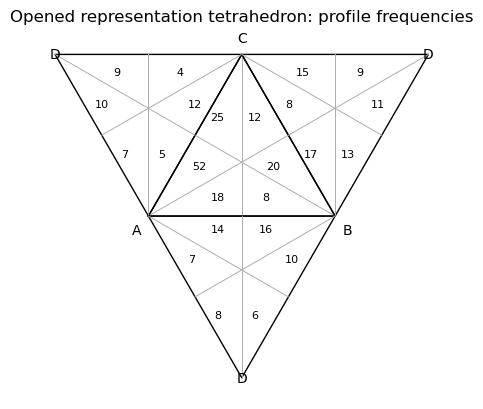

Python: <Axes: title={'center': 'Opened representation tetrahedron: profile frequencies'}>

In [56]:
ax = plot_profile_on_opened_tetrahedron(
    p4_freq;
    textsize = 8,
    title = "Opened representation tetrahedron: profile frequencies",
)
ax


In [57]:
outcome_functions = (
    plurality = plurality_4c_q_s,
    vote_for_two = vote_for_two_4c_q_s,
    antiplurality = antiplurality_4c_q_s,
    borda = borda_4c_q_s,
)

tetrahedron_points_from_profile(p4_freq, outcome_functions)


Dict{Symbol, Tuple{Float64, Float64, Float64}} with 4 entries:
  :antiplurality => (0.513713, 0.288066, 0.155892)
  :borda         => (0.494198, 0.289284, 0.14771)
  :plurality     => (0.469937, 0.256702, 0.136944)
  :vote_for_two  => (0.477057, 0.307402, 0.14082)

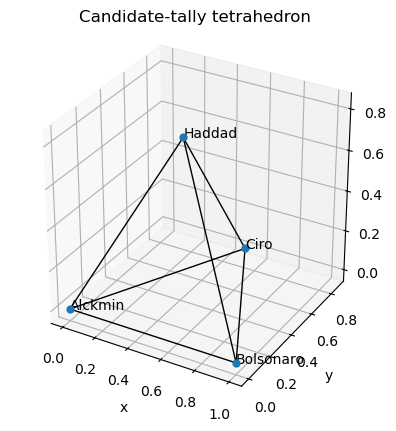

Python: <Axes3D: title={'center': 'Candidate-tally tetrahedron'}, xlabel='x', ylabel='y', zlabel='z'>

In [58]:
ax = plot_candidate_tally_tetrahedron(; labels = String.(labels4))
ax.set_title("Candidate-tally tetrahedron")
ax


## 8. The 24-dimensional Saari decomposition

The decomposition matrix is defined over the 24 canonical four-candidate ranking frequencies in the Saari Figure 8 order. `decompose_profile` stores coefficients and the 24 component vectors. Components can be reconstructed individually, by label groups, or all together.

Decomposition components are signed vectors, not profile frequencies. Use `plot_signed_profile_tetrahedron` or the decomposition plot helpers for them. The implemented labels are validated against source-defined election effects: `K4` and double reversals are kernel directions, Basic profiles have Saari's no-conflict behavior, Condorcet directions cancel for full positional rules while changing pairwise margins, and departure/positional directions cancel for pairwise and Borda but affect non-Borda positional rules.


In [59]:
source_basis = source_component_basis_matrix_4c()
implemented_basis = basis_matrix()

source_basis_matches_implemented_basis = (
    basic = isapprox(source_basis[:, 1:3], implemented_basis[:, 12:14]),
    condorcet = isapprox(source_basis[:, 4:6], implemented_basis[:, 15:17]),
    kernel = isapprox(source_basis[:, 7], implemented_basis[:, 18]),
    double_reversals = isapprox(source_basis[:, 8:13], implemented_basis[:, 19:24]),
)

(
    basis_identity = check_basis_identity(),
    source_basis_matches_implemented_basis = source_basis_matches_implemented_basis,
)


(basis_identity = true, source_basis_matches_implemented_basis = (basic = true, condorcet = true, kernel = true, double_reversals = true))

### 8.1 Source-derived component effects

This is a compact notebook-level check of the corrected basis semantics. The full test suite covers all six double reversals, all Basic profiles, the three Condorcet generators, subset checks, and random procedure-hull identities; this table keeps one representative of each source-defined effect visible in the walkthrough.


In [60]:
function pairwise_margin_tuple_4c(v)
    pairs = ((:AB, 1, 2), (:AC, 1, 3), (:AD, 1, 4), (:BC, 2, 3), (:BD, 2, 4), (:CD, 3, 4))
    out = Pair{Symbol,Float64}[]
    for (name, left, right) in pairs
        margin = 0.0
        for (weight, order) in zip(v, CANONICAL_4C_IDS)
            left_pos = findfirst(==(left), order)
            right_pos = findfirst(==(right), order)
            margin += left_pos < right_pos ? weight : -weight
        end
        push!(out, name => round(margin; digits = 3))
    end
    return (; out...)
end

function zero_vector(v; atol = 1e-9)
    return all(abs.(v) .<= atol)
end

function tied_vector(v; atol = 1e-9)
    return maximum(v) - minimum(v) <= atol
end

function component_effect_row(component, expected, v)
    plurality = get_4c_w_s(v, 0, 0)
    vote_for_two = get_4c_w_s(v, 1, 0)
    antiplurality = get_4c_w_s(v, 1, 1)
    borda = get_4c_w_s(v, 2 / 3, 1 / 3)
    pairwise = collect(values(pairwise_margin_tuple_4c(v)))
    return (
        component = component,
        expected = expected,
        vote_for_k_tied = all(tied_vector, (plurality, vote_for_two, antiplurality)),
        vote_for_k_zero = all(zero_vector, (plurality, vote_for_two, antiplurality)),
        vote_for_k_agree = isapprox(plurality, vote_for_two) && isapprox(vote_for_two, antiplurality),
        borda_zero = zero_vector(borda),
        pairwise_zero = all(abs.(pairwise) .<= 1e-9),
        pairwise_margins = pairwise_margin_tuple_4c(v),
    )
end

component_effect_rows = [
    component_effect_row("K4", "tied positional tallies; zero pairwise margins", kernel_profile_4c()),
    component_effect_row("double reversal AC", "kernel differential", double_reversal_differential_4c((1, 3))),
    component_effect_row("Basic A", "same vote-for-k effect; additive pairwise margins", basic_profile_differential_4c(1)),
    component_effect_row("Condorcet ABCD", "zero full positional tallies; nonzero pairwise margins", condorcet_profile_differential_4c((1, 2, 3, 4))),
    component_effect_row("departure Da", "zero pairwise and Borda; non-Borda positional effect", basis_matrix()[:, 1]),
]

component_effect_rows


5-element Vector{@NamedTuple{component::String, expected::String, vote_for_k_tied::Bool, vote_for_k_zero::Bool, vote_for_k_agree::Bool, borda_zero::Bool, pairwise_zero::Bool, pairwise_margins::@NamedTuple{AB::Float64, AC::Float64, AD::Float64, BC::Float64, BD::Float64, CD::Float64}}}:
 (component = "K4", expected = "tied positional tallies; zero pairwise margins", vote_for_k_tied = 1, vote_for_k_zero = 0, vote_for_k_agree = 0, borda_zero = 0, pairwise_zero = 1, pairwise_margins = (AB = 0.0, AC = 0.0, AD = 0.0, BC = 0.0, BD = 0.0, CD = 0.0))
 (component = "double reversal AC", expected = "kernel differential", vote_for_k_tied = 1, vote_for_k_zero = 1, vote_for_k_agree = 1, borda_zero = 1, pairwise_zero = 1, pairwise_margins = (AB = 0.0, AC = 0.0, AD = 0.0, BC = 0.0, BD = 0.0, CD = 0.0))
 (component = "Basic A", expected = "same vote-for-k effect; additive pairwise margins", vote_for_k_tied = 0, vote_for_k_zero = 0, vote_for_k_agree = 1, borda_zero = 0, pairwise_zero = 0, pairwise_margin

In [61]:
dec = decompose_profile(p4_freq)
reconstruction_error = maximum(abs.(reconstruct(dec) .- p4_freq))

nonzero_coefficients = [
    (index = i, label = COMPONENT_LABELS[i], coefficient = round(dec.coefficients[i]; digits = 4))
    for i in eachindex(COMPONENT_LABELS)
    if abs(dec.coefficients[i]) > 1e-9
]

(reconstruction_error, nonzero_coefficients)


(7.105427357601002e-15, @NamedTuple{index::Int64, label::Symbol, coefficient::Float64}[(index = 1, label = :Da, coefficient = -0.0417), (index = 2, label = :Db, coefficient = -4.2083), (index = 3, label = :Dc, coefficient = -1.9167), (index = 4, label = :departure_subset_1, coefficient = -7.5), (index = 5, label = :departure_subset_2, coefficient = -7.3333), (index = 6, label = :departure_subset_3, coefficient = 2.5), (index = 7, label = :departure_subset_4, coefficient = 6.1667), (index = 8, label = :departure_subset_5, coefficient = 1.5), (index = 9, label = :departure_subset_6, coefficient = 6.6667), (index = 10, label = :departure_subset_7, coefficient = 11.8333)  …  (index = 15, label = :Cabcd, coefficient = 0.375), (index = 16, label = :Cabdc, coefficient = 3.375), (index = 17, label = :Cacbd, coefficient = 3.75), (index = 18, label = :K, coefficient = 13.1667), (index = 19, label = :double_reversal_ac, coefficient = 5.625), (index = 20, label = :double_reversal_cb, coefficient =

In [62]:
groups = [
    :departure_differentials,
    :subset_departures,
    :basic_profile_differentials,
    :condorcet,
    :kernel,
    :double_reversals,
]

component_summary(dec; by = :group)


6-element Vector{@NamedTuple{label_or_group::Symbol, coefficient::Nothing, l1_norm::Float64, l2_norm::Float64, max_abs::Float64, norm_value::Float64, sum_component::Float64}}:
 (label_or_group = :departure_differentials, coefficient = nothing, l1_norm = 182.66666666666666, l2_norm = 43.59536162891135, max_abs = 14.500000000000002, norm_value = 43.59536162891135, sum_component = -1.7763568394002505e-15)
 (label_or_group = :subset_departures, coefficient = nothing, l1_norm = 235.33333333333331, l2_norm = 54.39975490140863, max_abs = 22.333333333333332, norm_value = 54.39975490140863, sum_component = 3.552713678800501e-15)
 (label_or_group = :basic_profile_differentials, coefficient = nothing, l1_norm = 94.66666666666663, l2_norm = 25.345391866942766, max_abs = 7.70833333333333, norm_value = 25.345391866942766, sum_component = 0.0)
 (label_or_group = :condorcet, coefficient = nothing, l1_norm = 60.0, l2_norm = 14.309088021254185, max_abs = 3.75, norm_value = 14.309088021254185, sum_compon

In [63]:
condorcet_component = group_component(dec, :condorcet)
double_reversal_component = group_component(dec, :double_reversals)

(
    condorcet_first_six = round.(condorcet_component[1:6]; digits = 4),
    double_reversal_first_six = round.(double_reversal_component[1:6]; digits = 4),
)


(condorcet_first_six = [0.375, 3.75, 3.375, -0.375, -3.75, -3.375], double_reversal_first_six = [10.75, 5.625, -5.625, 9.625, -9.625, -10.75])

### 8.2 Decomposition plots

The coefficient plot shows either basis coefficients by label or aggregate group norms. The opened tetrahedron plots below use signed markers so negative component mass is visually distinct from profile frequency.


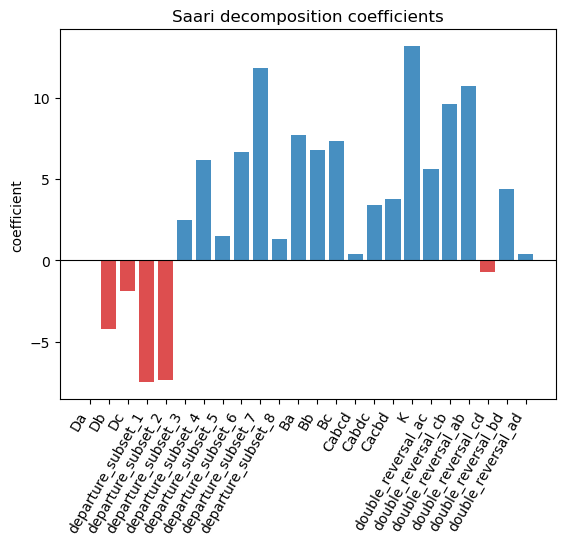

Python: <Axes: title={'center': 'Saari decomposition coefficients'}, ylabel='coefficient'>

In [64]:
ax = plot_decomposition_coefficients(dec; by = :label)
ax


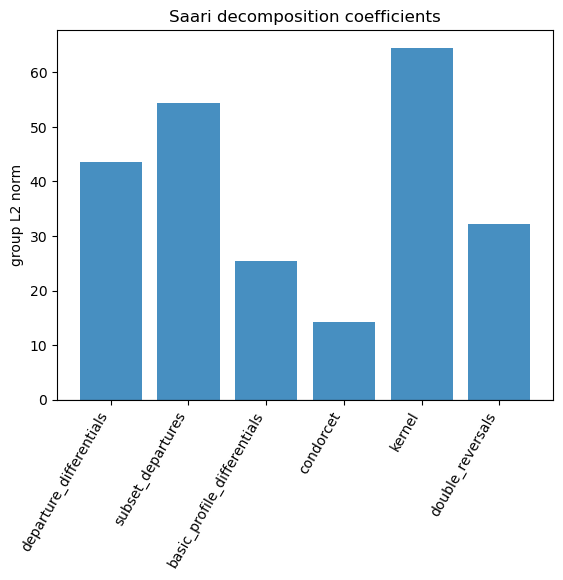

Python: <Axes: title={'center': 'Saari decomposition coefficients'}, ylabel='group L2 norm'>

In [65]:
ax = plot_decomposition_coefficients(dec; by = :group)
ax


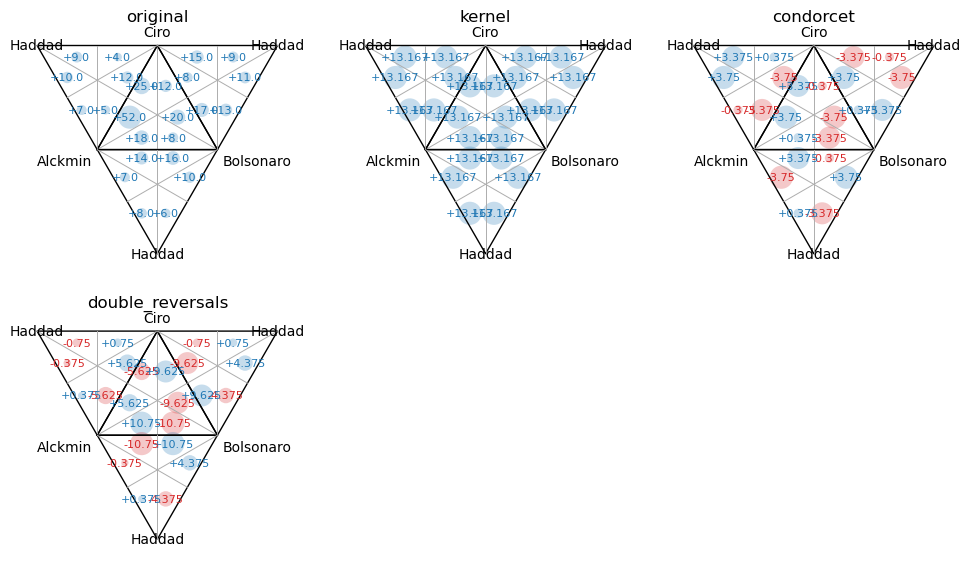

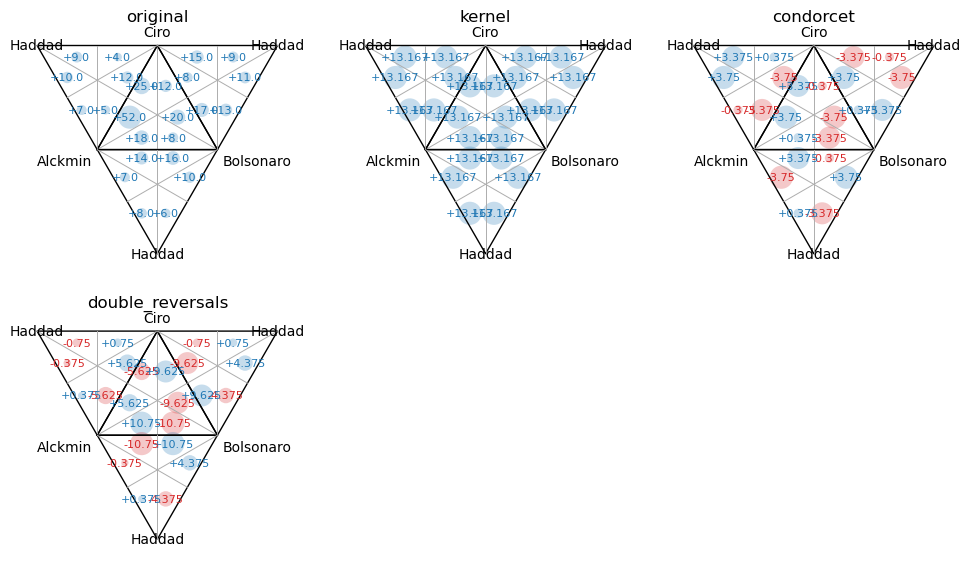

In [66]:
fig = plot_decomposition_component_tetrahedra(
    dec;
    groups = (:kernel, :condorcet, :double_reversals),
    labels = String.(labels4),
)
fig


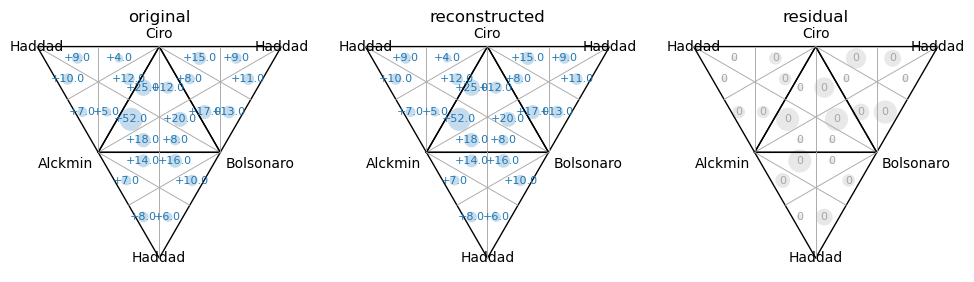

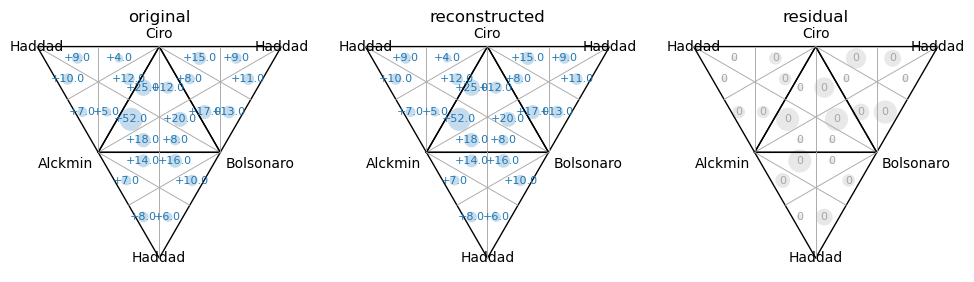

In [67]:
fig = plot_decomposition_reconstruction_check(dec; labels = String.(labels4))
fig


## 9. Minimal workflow template

This is the reusable shape for new analysis code. The input is already a `Preferences.Profile` or `Preferences.WeightedProfile`; survey loading and group construction should happen upstream.


In [68]:
function analyze_saari_profile(profile, basis::SaariBasis)
    freqs = profile_vector(profile, basis; normalize = false)
    props = profile_vector(profile, basis; normalize = true)
    labels = Preferences.candidates(basis.pool)

    if length(freqs) == 6
        methods = [
            (:plurality, plurality_3a(props)),
            (:borda, borda_3a(props)),
            (:antiplurality, antiplurality_3a(props)),
        ]
        return (
            frequencies = freqs,
            proportions = props,
            positional_results = positional_rows(methods, labels),
            triangle_points = triangle_points_from_profile(props),
        )
    elseif length(freqs) == 24
        methods = [
            (:plurality_q, plurality_4c_q_s(freqs)),
            (:vote_for_two_q, vote_for_two_4c_q_s(freqs)),
            (:antiplurality_q, antiplurality_4c_q_s(freqs)),
            (:borda_q, borda_4c_q_s(freqs)),
        ]
        dec = decompose_profile(freqs)
        hull = procedure_hull_4c(freqs; labels = String.(labels))
        return (
            frequencies = freqs,
            proportions = props,
            positional_results = positional_rows(methods, labels),
            procedure_hull = hull,
            decomposition = dec,
            component_norms = component_summary(dec; by = :group),
            reconstruction_error = maximum(abs.(reconstruct(dec) .- freqs)),
        )
    else
        throw(ArgumentError("Saari workflow expects a 3- or 4-candidate basis"))
    end
end

analysis4 = analyze_saari_profile(brazil_profile, brazil_basis)
(
    reconstruction_error = analysis4.reconstruction_error,
    borda_barycentric = analysis4.procedure_hull.borda_barycentric,
)


(reconstruction_error = 7.105427357601002e-15, borda_barycentric = (0.33333333333333337, 0.3333333333333333, 0.3333333333333333))

## 10. Exercises

1. Change `beverage_counts` so plurality and Borda choose different winners, then redraw the Saari triangle.
2. Convert the beverage example to a `WeightedProfile` with fractional weights and compare normalized and unnormalized vectors.
3. Modify `brazil_counts` and rerun the procedure-hull cells. Check that Borda remains the centroid of the raw vote-for-k tallies.
4. Use `Preferences.restrict` to compare all three-candidate subprofiles and record which candidate-dropping choice changes the Borda winner.
5. Reconstruct only the `:condorcet` and `:double_reversals` decomposition groups and inspect which canonical rankings carry the largest signed mass.
6. Compare `source_component_basis_matrix_4c()` against selected columns of `basis_matrix()` after changing `CANONICAL_4C_IDS`; the effect checks should catch an ordering mistake.
7. Add a `PrefPol` adapter later that returns a strict `Preferences.Profile`, then reuse `analyze_saari_profile` without changing `VotingGeometry`.

Not included yet: transfer-algorithm examples. That routine was deliberately left out of the first `VotingGeometry.jl` pass.
